# Support Ticket Classification: Pipeline 2
* **Course**: CM52065 Natural Language Processing
* **Author**: Shivangi Malik

## Overview
This notebook uses the below approach on the `cw_data.csv` dataset, shared as part of the coursework:
* **Pre-processing:** Domain normalisation - Tokenisation - Stop Word Removal - **Lemmatisation**
* **Represenatation:** **Word2Vec** Sentence Embeddings
* **Classifier:** Gaussian Naive Bayes
You will also find a thorough evaluation using F1 score, visualisation of the results through a Confusion Matrix and an error analysis on the true and predicted value.
* **Evaluation:** Accuracy, Precision, Recall, F1 score, Confusion Matrix and Error Analysis<br>

---
*Place `cw_data.csv` in the same folder as this notebook.*

## Initial Setup

In [1]:
import subprocess, sys

# Installing required packages, if not installed already.
# In case the requirements are met, there will be no impact.
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'gensim', 'nltk', 'scikit-learn',
     'pandas', 'numpy', 'matplotlib', 'seaborn'],
    capture_output=True
)

# Added the ssl check to bypass the macOS local ssl cert verification
# while downloading NLTK corpora.
import ssl
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass

# Download NLTK data
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    nltk.download(pkg, quiet=True)

# Importing core libraries, NLP tools and scikit-learn components
import re, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer   # for Lab 1 comparison only

import gensim
_v = int(gensim.__version__.split('.')[0])
if _v < 4:
    raise ImportError(
        f"gensim {gensim.__version__} found. This notebook needs gensim 4.x.\n"
        "Run:  pip install --upgrade gensim"
    )
from gensim.models import Word2Vec

from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
# Using seed to ensure reproducibility
SEED = 42
np.random.seed(SEED)
PALETTE = sns.color_palette('tab10', 14)

print(f"All requirements are met!")

All requirements are met!


### Loading the dataset

In [ ]:
# Check if the cw_data.csv file exists and handle the code if opened in google colab
import os
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import files
    print("Upload cw_data.csv using the file picker below:")
    uploaded = files.upload()
    print("cw_data.csv exists. Loading the dataset now...")
else:
    assert os.path.exists('cw_data.csv'), \
        "ERROR: place cw_data.csv in the same folder as this notebook."
    print("cw_data.csv exists. Loading the dataset now...")

# Load the dataset
df = pd.read_csv('cw_data.csv', header=None, names=['query', 'category'])
df['query']    = df['query'].astype(str).str.strip()
df['category'] = df['category'].astype(str).str.strip()

print(f"Total Samples: {len(df)}  |  Support Ticket Types: {df['category'].nunique()}")
print(f"Avg query length: {df['query'].str.len().mean():.1f} characters")
print(f"\nClass distribution:")
print(df['category'].value_counts().to_string())

cw_data.csv found! Loading the dataset now...
Total Samples: 308  |  Support Ticket Types: 14
Avg query length: 40.5 characters

Class distribution:
category
payment_issue              33
shipping_delay             29
notification_settings      24
update_email               23
subscription_management    23
delete_account             23
order_tracking             22
data_privacy               22
account_recovery           21
billing_history            21
refund_request             21
reset_password             20
login_issue                16
two_factor_auth            10


## Part 1: Pre-processing Pipeline
The following steps are implemented to carry out the pre-processing
1. Expanding domain abbreviations using mannual mapping based on corpus analysis
2. Lowercase and punctuation removal
3. Stop Word Removal using `nltk.corpus.stopwords`
4. Lemmatisation using `WordNetLemmatizer`

In [3]:
# Domain abbreviation mapping
DOMAIN_ABBREVS = {
    'acct':'account',
    'auth':'authentication',
    '2fa':'two factor authentication',
    'tfa':'two factor authentication',
    'pwd':'password',
    'pswd':'password',
    'pass':'password',
    'pls':'please',
    'plz':'please',
    'wat':'what',
    'msg':'message',
    'info':'information',
    'notif':'notification',
    'notifs':'notifications',
    'del':'delete',
    'sub':'subscription',
    'refnd':'refund',
    'trk':'tracking',
    'addr':'address',
    'priv':'privacy',
    'paymt':'payment',
    'pmt':'payment',
    'verif':'verification',
    'u':'you',
    'ur':'your',
    'thx':'thanks',
    'idk':'i do not know',
}

# Stopword removal but retaining the negations
STOP_WORDS = set(nltk_stopwords.words('english'))
STOP_WORDS -= {'not', 'no', 'nor', 'never', 'without', 'cannot'}

# Performa lemmatisation
lemmatiser = WordNetLemmatizer()

def preprocess_p2(text: str) -> list:
    text = text.lower()
    tokens = re.findall(r'[a-z0-9]+', text)
    expanded = []
    for t in tokens:
        expanded.extend(DOMAIN_ABBREVS.get(t, t).split())
    tokens = [t for t in expanded if t.isalpha()
              and t not in STOP_WORDS and len(t) > 1]
    tokens = [lemmatiser.lemmatize(t) for t in tokens]
    return tokens

df['tokens_p2']    = df['query'].apply(preprocess_p2)
df['processed_p2'] = df['tokens_p2'].apply(lambda t: ' '.join(t))

# Demonstrating the reduction in vocabulary after lemmatisation as compared to the raw vocabulary
raw_vocab   = set(w for q in df['query'].str.lower() for w in q.split())
lemma_vocab = set(w for toks in df['tokens_p2'] for w in toks)
print(f"Raw vocabulary  : {len(raw_vocab):,}")
print(f"After lemmatise : {len(lemma_vocab):,}")
print(f"Reduction       : {(1-len(lemma_vocab)/len(raw_vocab))*100:.1f}%")
print()
print("Pre-processing examples:")
print(f"{'Original':<45}  →  {'Tokens'}")
print('─' * 80)
for _, row in df.head(5).iterrows():
    print(f"{row['query'][:45]:<45}  →  {row['tokens_p2']}")

Raw vocabulary  : 525
After lemmatise : 328
Reduction       : 37.5%

Pre-processing examples:
Original                                       →  Tokens
────────────────────────────────────────────────────────────────────────────────
tracking shows shipped but no delivery help p  →  ['tracking', 'show', 'shipped', 'no', 'delivery', 'help', 'please']
partial shipments tracked separately?          →  ['partial', 'shipment', 'tracked', 'separately']
invalid email entered wat happens?             →  ['invalid', 'email', 'entered', 'happens']
recover acct if suspended?                     →  ['recover', 'account', 'suspended']
emial update failed error — fix?               →  ['emial', 'update', 'failed', 'error', 'fix']


## Part 2: Classification Model

### Word2Vec Embeddings Representation

In [4]:
corpus_tokens = df['tokens_p2'].tolist()

w2v_model = Word2Vec(
    sentences   = corpus_tokens,
    vector_size = 100,
    window      = 1,
    min_count   = 1,
    sg          = 0,
    seed        = SEED,
    workers     = 1,
)

print(f"Word2Vec trained:")
print(f"  Vocabulary : {len(w2v_model.wv):,} words")
print(f"  Vector size: {w2v_model.vector_size} dimensions")
print(f"  Architecture: CBOW (sg=0)")

Word2Vec trained:
  Vocabulary : 328 words
  Vector size: 100 dimensions
  Architecture: CBOW (sg=0)


### Word Similarity Analysis

In [5]:
print("Word similarity:")
print(f"{'Word pair':<35}  {'Cosine Similarity':>18}")
print('─' * 56)
for w1, w2 in [('account','password'),('payment','billing'),
               ('shipping','tracking'),('login','authentication')]:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        pair = f"{w1} - {w2}"
        print(f"{pair:<35}  {sim:>18.4f}")

print("\nMost similar words:")
for word in ['account', 'payment', 'password']:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=3)
        print(f"  '{word}': {[(w, round(s,3)) for w,s in sims]}")

Word similarity:
Word pair                             Cosine Similarity
────────────────────────────────────────────────────────
account - password                               0.2034
payment - billing                               -0.1181
shipping - tracking                             -0.1111
login - authentication                          -0.0841

Most similar words:
  'account': [('duplicate', 0.283), ('tip', 0.27), ('message', 0.236)]
  'payment': [('midway', 0.316), ('erased', 0.257), ('entered', 0.248)]
  'password': [('express', 0.301), ('using', 0.266), ('working', 0.265)]


## Sentence Embeddings

In [6]:
# Extend word-level embeddings to sentence level by averaging
def sentence_embedding(tokens: list) -> np.ndarray:
    """Average Word2Vec vectors for all known tokens — sentence-level embedding."""
    vecs = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if not vecs:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vecs, axis=0)

X_embeddings = np.array([sentence_embedding(t) for t in df['tokens_p2']])
print(f"Embedding matrix: {X_embeddings.shape}")
print(f"  {X_embeddings.shape[0]} queries × {X_embeddings.shape[1]} dimensions")

# Cosine similarity between category representatives
print("\nCosine similarity between category:")
def get_emb(cat):
    rows = df[df['category']==cat]
    return sentence_embedding(rows.iloc[0]['tokens_p2']) if len(rows) else None

print(f"{'Category A':<25}  {'Category B':<25}  {'Similarity':>10}")
print('─' * 65)
for ca, cb in [('login_issue','account_recovery'),
               ('login_issue','shipping_delay'),
               ('payment_issue','billing_history')]:
    ea, eb = get_emb(ca), get_emb(cb)
    if ea is not None and eb is not None:
        sim = cosine_similarity(ea.reshape(1,-1), eb.reshape(1,-1))[0][0]
        print(f"  {ca:<25}  {cb:<25}  {sim:>10.4f}")

Embedding matrix: (308, 100)
  308 queries × 100 dimensions

Cosine similarity between category:
Category A                 Category B                 Similarity
─────────────────────────────────────────────────────────────────
  login_issue                account_recovery               0.3073
  login_issue                shipping_delay                -0.0420
  payment_issue              billing_history                0.0706


### Split the dataset into Train and Test data

In [7]:
y = df['category'].tolist()

X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Training: {len(X_train_emb)}  |  Test: {len(X_test_emb)}")

Training: 246  |  Test: 62


## Gaussian Naive Bayes Model

In [8]:
gnb = GaussianNB()
gnb.fit(X_train_emb, y_train)
y_pred = gnb.predict(X_test_emb)
print("Model trained succesfully!")

Model trained succesfully!


## Evaluation
Evaluating the results based on **accuracy**, **precision**, **recall** and **F1 score** (harmonic mean of precision and recall) metrics to give a balanced analysis because the dataset has mild class imbalance (10–33 samples per class).

In [9]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

print("=" * 50)
print("  PIPELINE 2 — EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Macro Precision   : {prec:.4f}")
print(f"  Macro Recall      : {rec:.4f}")
print(f"  Macro F1          : {f1:.4f}")
print("=" * 50)
print()
print("Per-class breakdown:")
print(classification_report(y_test, y_pred,
                             target_names=sorted(set(y))))

  PIPELINE 2 — EVALUATION RESULTS
  Accuracy          : 0.7742
  Macro Precision   : 0.8304
  Macro Recall      : 0.7600
  Macro F1          : 0.7772

Per-class breakdown:
                         precision    recall  f1-score   support

       account_recovery       0.75      0.75      0.75         4
        billing_history       0.67      0.50      0.57         4
           data_privacy       1.00      0.75      0.86         4
         delete_account       1.00      0.60      0.75         5
            login_issue       1.00      1.00      1.00         3
  notification_settings       1.00      1.00      1.00         5
         order_tracking       0.67      0.50      0.57         4
          payment_issue       0.75      0.86      0.80         7
         refund_request       1.00      0.75      0.86         4
         reset_password       1.00      1.00      1.00         4
         shipping_delay       0.62      0.83      0.71         6
subscription_management       0.50      0.80   

### Confusion Matrix

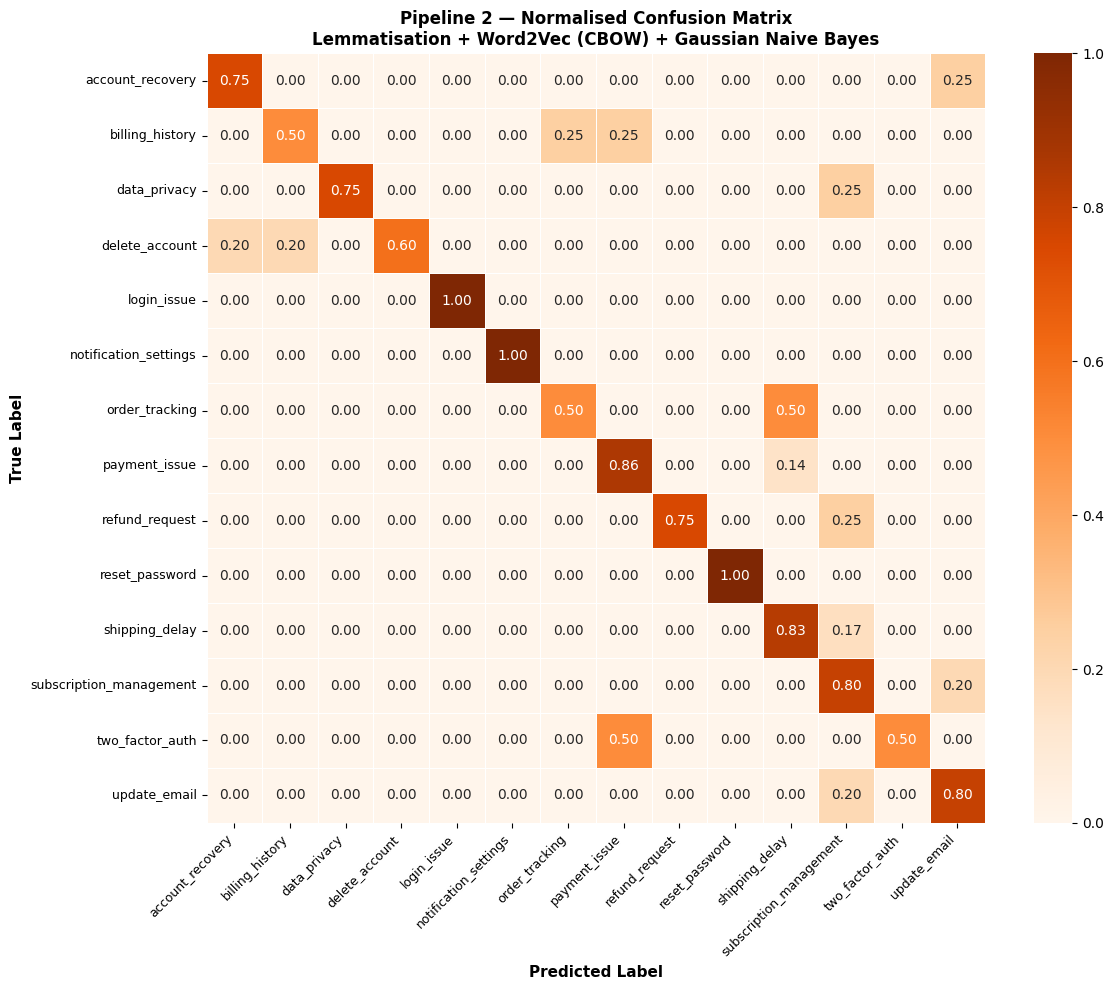

In [10]:
labels = sorted(set(y))
cm2 = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm2, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.4, linecolor='white', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=11, fontweight='bold')
ax.set_title(
    'Pipeline 2 — Normalised Confusion Matrix\n'
    'Lemmatisation + Word2Vec (CBOW) + Gaussian Naive Bayes',
    fontsize=12, fontweight='bold'
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('p2_confusion_matrix.png', bbox_inches='tight')
plt.show()

### PCA Visualisation of Word2Vec Space

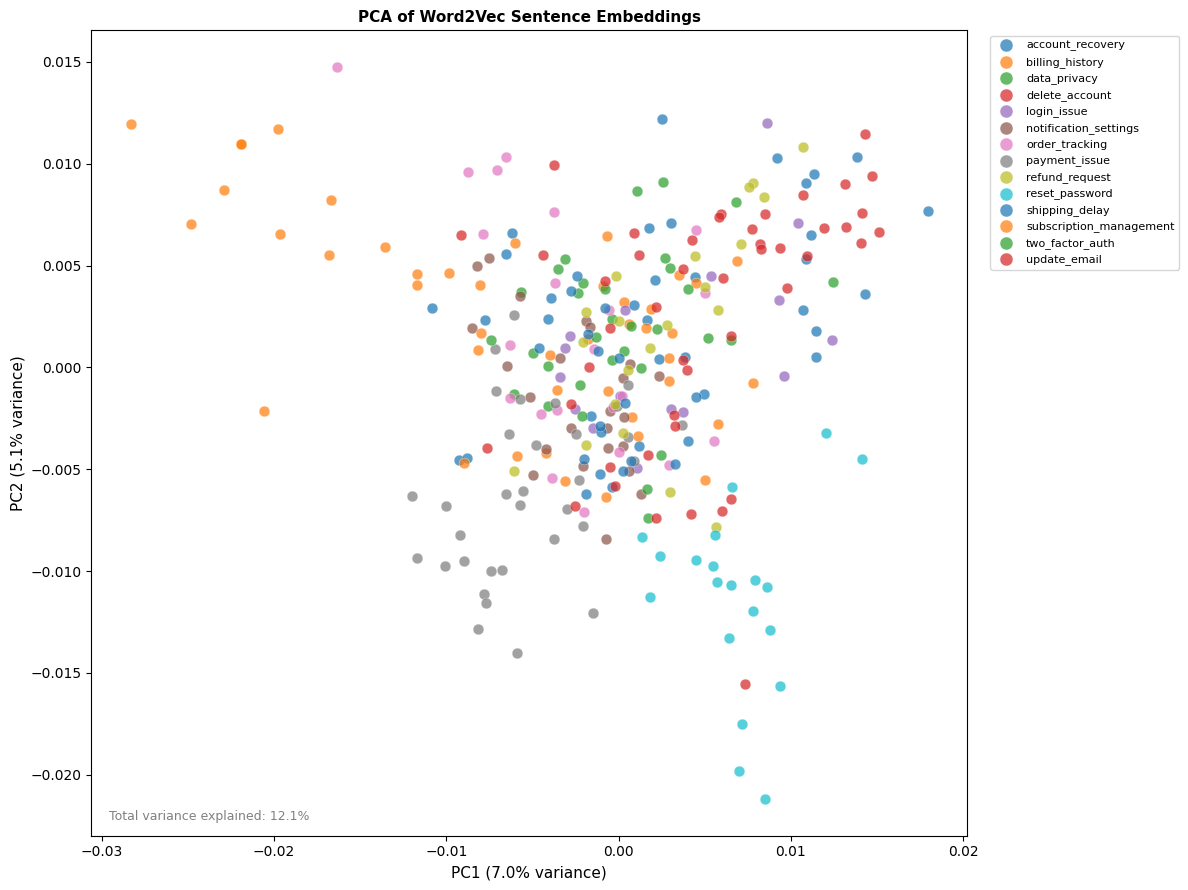

In [11]:
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_embeddings)

le = LabelEncoder()
y_enc = le.fit_transform(y)

fig, ax = plt.subplots(figsize=(12, 9))
for i, cls in enumerate(le.classes_):
    mask = (y_enc == i)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=PALETTE[i % len(PALETTE)],
               alpha=0.72, s=60, edgecolors='white', linewidths=0.3, label=cls)

total_var = pca.explained_variance_ratio_.sum() * 100
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(
    'PCA of Word2Vec Sentence Embeddings',
    fontsize=11, fontweight='bold'
)
ax.text(0.02, 0.02, f'Total variance explained: {total_var:.1f}%',
        transform=ax.transAxes, fontsize=9, color='grey')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, framealpha=0.8, markerscale=1.2)
plt.tight_layout()
plt.savefig('p2_pca.png', bbox_inches='tight')
plt.show()

### Error Analysis
Inspecting queries that were wrongly classified.

In [12]:
test_queries = df['query'].iloc[
    len(X_train_emb):len(X_train_emb)+len(X_test_emb)].tolist()

errors = [
    {'query':q,'true':t,'predicted':p}
    for q,t,p in zip(test_queries, y_test, y_pred) if t != p
]

print(f"Misclassified: {len(errors)} / {len(y_test)}  "
      f"({len(errors)/len(y_test)*100:.1f}% error rate)\n")
print(f"{'Query':<50}  {'True Label':<25}  Predicted")
print('─' * 100)
for e in errors[:15]:
    print(f"{e['query'][:50]:<50}  {e['true']:<25}  {e['predicted']}")

print("\nMost common confusion pairs (true -> predicted):")
for (t,p), cnt in Counter(
        [(e['true'],e['predicted']) for e in errors]).most_common(6):
    print(f"  {t:<30} → {p:<30}  ({cnt}x)")

Misclassified: 14 / 62  (22.6% error rate)

Query                                               True Label                 Predicted
────────────────────────────────────────────────────────────────────────────────────────────────────
I'm unable to sign in — is this because my account  order_tracking             shipping_delay
limit on number of refunds?                         billing_history            order_tracking
billing info mismatch after payment?                delete_account             billing_history
How do I reset my password within 48 hours; does t  account_recovery           update_email
notification delay on email/app wat 2 do?           payment_issue              shipping_delay
share tracking info possible?                       billing_history            payment_issue
why courier not updating tracking info?             order_tracking             shipping_delay
shipping delays common France?                      delete_account             account_recovery
package lost d

## Summary

In [13]:
print("=" * 52)
print("  PIPELINE 2 — RESULTS SUMMARY")
print("=" * 52)
print(f"  Pre-processing : Lemmatisation")
print(f"  Representation : Word2Vec CBOW")
print(f"  Classifier     : Gaussian Naive Bayes")
print('─' * 52)
print(f"  Accuracy       : {acc:.4f}")
print(f"  Macro Precision: {prec:.4f}")
print(f"  Macro Recall   : {rec:.4f}")
print(f"  Macro F1       : {f1:.4f}")
print("=" * 52)

  PIPELINE 2 — RESULTS SUMMARY
  Pre-processing : Lemmatisation
  Representation : Word2Vec CBOW
  Classifier     : Gaussian Naive Bayes
────────────────────────────────────────────────────
  Accuracy       : 0.7742
  Macro Precision: 0.8304
  Macro Recall   : 0.7600
  Macro F1       : 0.7772
